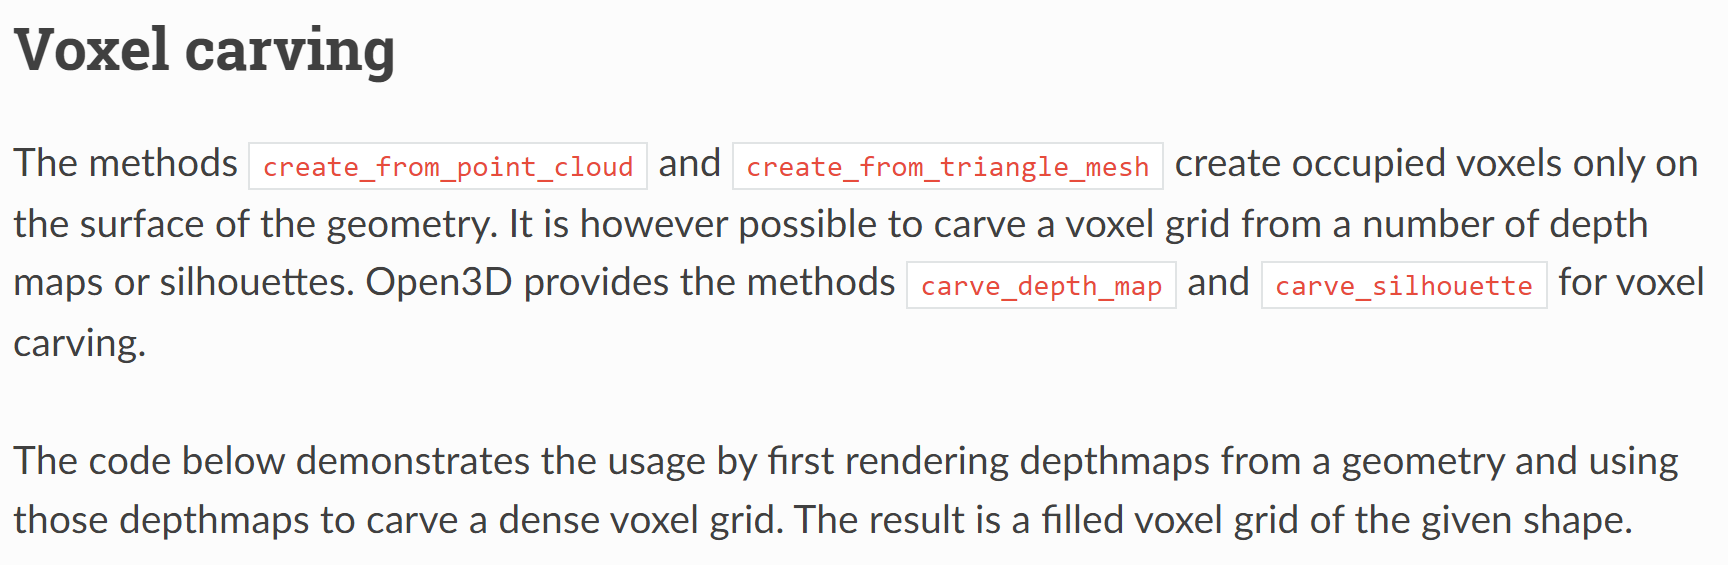

In [1]:
import open3d as o3d
import numpy as np

# 將三維直角座標 xyz 轉換成球座標 (r, r_x, r_y)
# r  ：點到原點的距離
# r_x：與 y 軸的夾角（用 arccos 計算）
# r_y：在 x–z 平面上的方位角（用 arctan2 計算）
def xyz_spherical(xyz):
    x = xyz[0]
    y = xyz[1]
    z = xyz[2]
    r = np.sqrt(x * x + y * y + z * z)
    r_x = np.arccos(y / r)
    r_y = np.arctan2(z, x)
    return [r, r_x, r_y]


# 根據兩個角度 r_x, r_y 建立旋轉矩陣
# r_x：繞 x 軸旋轉的角度
# r_y：繞 y 軸旋轉的角度
# 回傳：先繞 x 再繞 y 的 3x3 旋轉矩陣
def get_rotation_matrix(r_x, r_y):
    # x 軸旋轉矩陣
    rot_x = np.asarray([[1, 0, 0],
                        [0, np.cos(r_x), -np.sin(r_x)],
                        [0, np.sin(r_x), np.cos(r_x)]])
    # y 軸旋轉矩陣
    rot_y = np.asarray([[np.cos(r_y), 0, np.sin(r_y)],
                        [0, 1, 0],
                        [-np.sin(r_y), 0, np.cos(r_y)]])
    # 先 rot_x 再 rot_y
    return rot_y.dot(rot_x)


# 根據一個 3D 位置 xyz 產生相機的 4x4 外部參數矩陣 (extrinsic)
# 這裡的設計是：
#   - 利用 xyz 的方向決定相機的旋轉（由球座標換成旋轉矩陣）
#   - 平移 t 固定放在 [0, 0, 2]
# 回傳：4x4 齊次變換矩陣（旋轉 + 平移）
def get_extrinsic(xyz):
    # 把 xyz 轉成球座標，取出兩個角 r_x, r_y
    rvec = xyz_spherical(xyz)
    r = get_rotation_matrix(rvec[1], rvec[2])
    # 相機的位置（平移向量），這邊固定在 z=2 的位置
    t = np.asarray([0, 0, 2]).transpose()
    # 組 4x4 齊次變換矩陣
    trans = np.eye(4)
    trans[:3, :3] = r
    trans[:3, 3] = t
    return trans


# 對輸入的 mesh 做「中心化 + 正規化」的預處理
# 目的：
#   - 把 mesh 移到原點附近（減去中心）
#   - 再依 bounding box 的大小做縮放，讓模型落在 [-1, 1] 立方體左右的範圍
def preprocess(model):
    # 取得 mesh 的 AABB 最小與最大點
    min_bound = model.get_min_bound()
    max_bound = model.get_max_bound()
    # 計算中心點與尺度
    center = min_bound + (max_bound - min_bound) / 2.0
    scale = np.linalg.norm(max_bound - min_bound) / 2.0
    # 對頂點做平移與縮放
    vertices = np.asarray(model.vertices)
    vertices -= center
    model.vertices = o3d.utility.Vector3dVector(vertices / scale)
    return model


# 主要的 voxel carving 函式
# mesh            ：輸入的三角網格模型
# cubic_size      ：voxel grid 立方體的物理尺寸（邊長）
# voxel_resolution：voxel grid 在一個維度上的解析度（例如 256 -> 256^3）
# w, h            ：用來 render depth map 的視窗寬高
# use_depth       ：True -> 用 depth map carving；False -> 用 silhouette carving
# surface_method  ：'pointcloud' 或 'mesh'，用哪一種幾何來建表面的 voxel grid
# 回傳：
#   voxel_carving_surface：surface voxel + carving 結果疊加
#   voxel_carving        ：carving 後剩下的 voxel grid（體素內部）
#   voxel_surface        ：由 point cloud 或 mesh 建出來的外表面 voxel grid
def voxel_carving(mesh,
                  cubic_size,
                  voxel_resolution,
                  w=300,
                  h=300,
                  use_depth=False,
                  surface_method='pointcloud'):
    # 先計算法向量，讓渲染結果比較正確
    mesh.compute_vertex_normals()
    # 建一個球來當「相機軌道」，球面上的點是相機位置參考
    camera_sphere = o3d.geometry.TriangleMesh.create_sphere()

    # === 建立 dense voxel grid（體素立方體） ===
    voxel_carving = o3d.geometry.VoxelGrid.create_dense(
        width=cubic_size,
        height=cubic_size,
        depth=cubic_size,
        voxel_size=cubic_size / voxel_resolution,
        # 立方體的左下後角在 (-cubic_size/2, -cubic_size/2, -cubic_size/2)
        origin=[-cubic_size / 2.0, -cubic_size / 2.0, -cubic_size / 2.0],
        color=[1.0, 0.7, 0.0])  # 體素顏色（橘色）
    o3d.visualization.draw_geometries([voxel_carving])
    
    # === 將相機球與 mesh 做中心化 + 縮放，放進同一個 [-1,1]^3 空間 ===
    camera_sphere = preprocess(camera_sphere)
    mesh = preprocess(mesh)

    # === 建立一個「看不見視窗的」Visualizer，用來 Render 深度影像 ===
    vis = o3d.visualization.Visualizer()
    vis.create_window(width=w, height=h, visible=False)  # invisible offscreen window
    vis.add_geometry(mesh)
    # 顯示背面，以免某些角度看不到幾何
    vis.get_render_option().mesh_show_back_face = True
    ctr = vis.get_view_control()
    # 取得 pinhole camera 的參數（內部+外部）
    param = ctr.convert_to_pinhole_camera_parameters()

    # === 開始繞著模型做 voxel carving ===
    pcd_agg = o3d.geometry.PointCloud()                 # 累積所有視角的點雲
    centers_pts = np.zeros((len(camera_sphere.vertices), 3))  # 記錄相機中心位置
    for cid, xyz in enumerate(camera_sphere.vertices):
        # 1. 依照球面上的一個點 xyz，計算對應相機的外部矩陣
        trans = get_extrinsic(xyz)
        param.extrinsic = trans
        # 相機中心 c = trans^-1 * [0,0,0,1]^T
        c = np.linalg.inv(trans).dot(np.asarray([0, 0, 0, 1]).transpose())
        centers_pts[cid, :] = c[:3]
        # 更新視角，allow_arbitrary=True 允許非預設姿態
        ctr.convert_from_pinhole_camera_parameters(param, allow_arbitrary=True)

        # 2. 渲染深度圖（depth map），再轉成點雲
        vis.poll_events()
        vis.update_renderer()
        depth = vis.capture_depth_float_buffer(False)  # 取得深度影像（float buffer）
        pcd_agg += o3d.geometry.PointCloud.create_from_depth_image(
            o3d.geometry.Image(depth),
            param.intrinsic,
            param.extrinsic,
            depth_scale=1)   # 這裡深度就是 meter / world unit，所以 scale=1
        
        # 3. 用深度圖對 voxel grid 做 carving（體素刨除）
        #    use_depth=True  -> 使用 carve_depth_map
        #    use_depth=False -> 使用 carve_silhouette
        if use_depth:
            # 利用 depth map 保留靠近表面的體素，刨除其他部分
            voxel_carving.carve_depth_map(o3d.geometry.Image(depth), param)
        else:
            # 只根據前景/背景 silhouette 來刨除 voxels
            voxel_carving.carve_silhouette(o3d.geometry.Image(depth), param)
        print("Carve view %03d/%03d" % (cid + 1, len(camera_sphere.vertices)))
        
    vis.destroy_window()

    # === 從 carved 出來的點雲或 mesh 建立「表面」的 voxel grid ===
    print('Surface voxel grid from %s' % surface_method)
    if surface_method == 'pointcloud':
        # 用累積的點雲 pcd_agg 建 voxel grid（表面）
        voxel_surface = o3d.geometry.VoxelGrid.create_from_point_cloud_within_bounds(
            pcd_agg,
            voxel_size=cubic_size / voxel_resolution,
            min_bound=(-cubic_size / 2, -cubic_size / 2, -cubic_size / 2),
            max_bound=(cubic_size / 2, cubic_size / 2, cubic_size / 2))
    elif surface_method == 'mesh':
        # 直接用 mesh 幾何來建 voxel grid（表面）
        voxel_surface = o3d.geometry.VoxelGrid.create_from_triangle_mesh_within_bounds(
            mesh,
            voxel_size=cubic_size / voxel_resolution,
            min_bound=(-cubic_size / 2, -cubic_size / 2, -cubic_size / 2),
            max_bound=(cubic_size / 2, cubic_size / 2, cubic_size / 2))
    else:
        raise Exception('invalid surface method')

    # voxel_carving_surface = 表面 voxel + 體積 carving 結果疊加
    voxel_carving_surface = voxel_surface + voxel_carving

    return voxel_carving_surface, voxel_carving, voxel_surface
    

# === 測試：讀取範例 Armadillo mesh，並做 voxel carving ===
armadillo = o3d.data.BunnyMesh()
mesh = o3d.io.read_triangle_mesh(armadillo.path)
o3d.visualization.draw_geometries([mesh])

visualization = True
cubic_size = 2.0         # voxel 空間的立方體邊長
voxel_resolution = 128 # 每一維的 voxel 數量

# 執行 voxel carving，得到：
#   voxel_grid        ：表面 + 體積的綜合結果
#   voxel_carving     ：純 carving 過後的體素（內部／實心）
#   voxel_surface     ：由點雲或 mesh 建出來的表面體素
voxel_grid, voxel_carving, voxel_surface = voxel_carving(
    mesh, cubic_size, voxel_resolution
)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Carve view 001/762
Carve view 002/762
Carve view 003/762
Carve view 004/762
Carve view 005/762
Carve view 006/762
Carve view 007/762
Carve view 008/762
Carve view 009/762
Carve view 010/762
Carve view 011/762
Carve view 012/762
Carve view 013/762
Carve view 014/762
Carve view 015/762
Carve view 016/762
Carve view 017/762
Carve view 018/762
Carve view 019/762
Carve view 020/762
Carve view 021/762
Carve view 022/762
Carve view 023/762
Carve view 024/762
Carve view 025/762
Carve view 026/762
Carve view 027/762
Carve view 028/762
Carve view 029/762
Carve view 030/762
Carve view 031/762
Carve view 032/762
Carve view 033/762
Carve view 034/762
Carve view 035/762
Carve view 036/762
Carve view 037/762
Carve view 038/762
Carve view 039/762
Carve view 040/762
Carve view 041/762
Carve view 042/762
Carve view 043/762
Carve view 044

In [2]:
print("surface voxels")
print(voxel_surface)
o3d.visualization.draw_geometries([voxel_surface])

print("carved voxels")
print(voxel_carving)
o3d.visualization.draw_geometries([voxel_carving])

print("combined voxels (carved + surface)")
print(voxel_grid)
o3d.visualization.draw_geometries([voxel_grid])

o3d.io.write_voxel_grid("voxel_surface.ply", voxel_surface)
o3d.io.write_voxel_grid("voxel_carving.ply", voxel_carving)
o3d.io.write_voxel_grid("voxel_grid.ply", voxel_grid)


surface voxels
VoxelGrid with 23563 voxels.
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: 未支援要求的格式變更操作。 
carved voxels
VoxelGrid with 116924 voxels.
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: 控制代碼無效。 
combined voxels (carved + surface)
VoxelGrid with 117313 voxels.


True

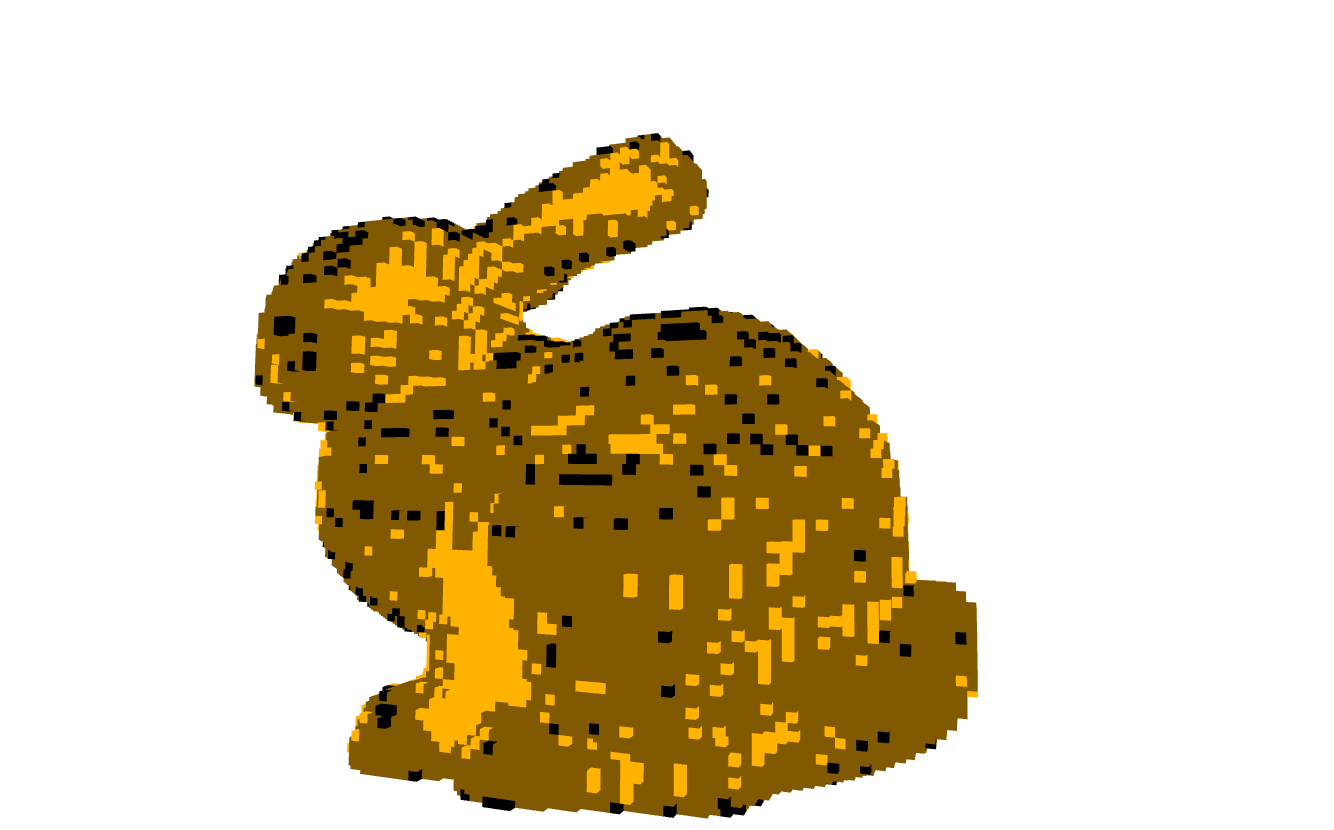

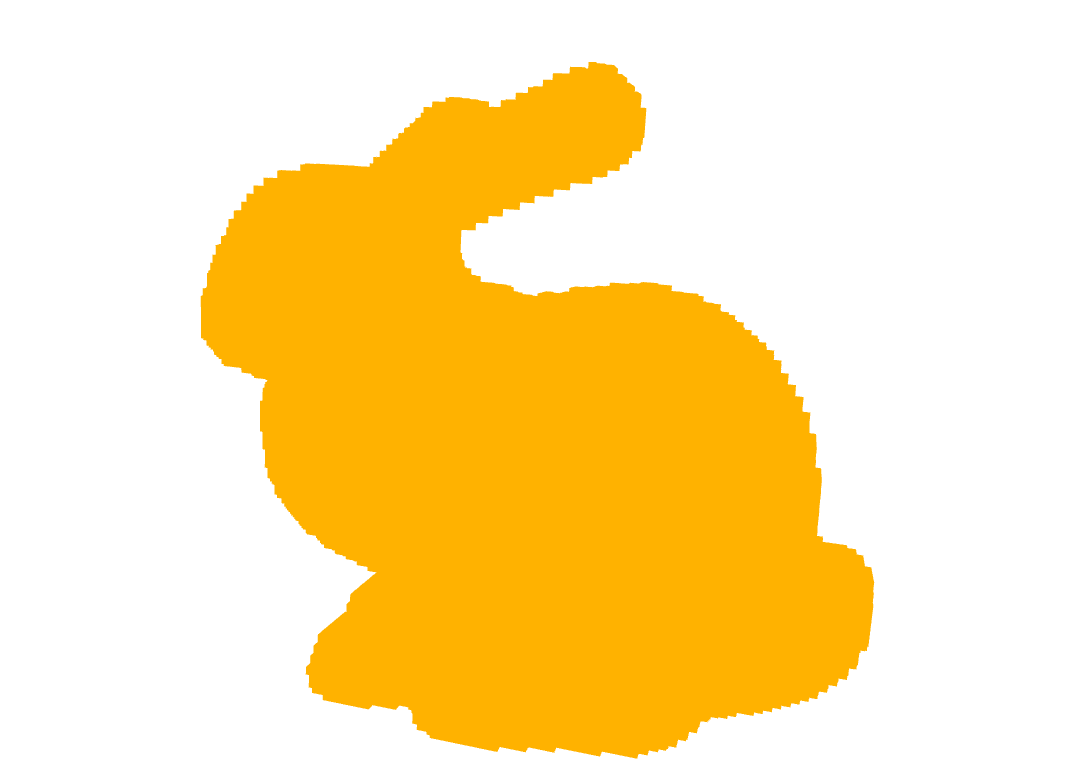

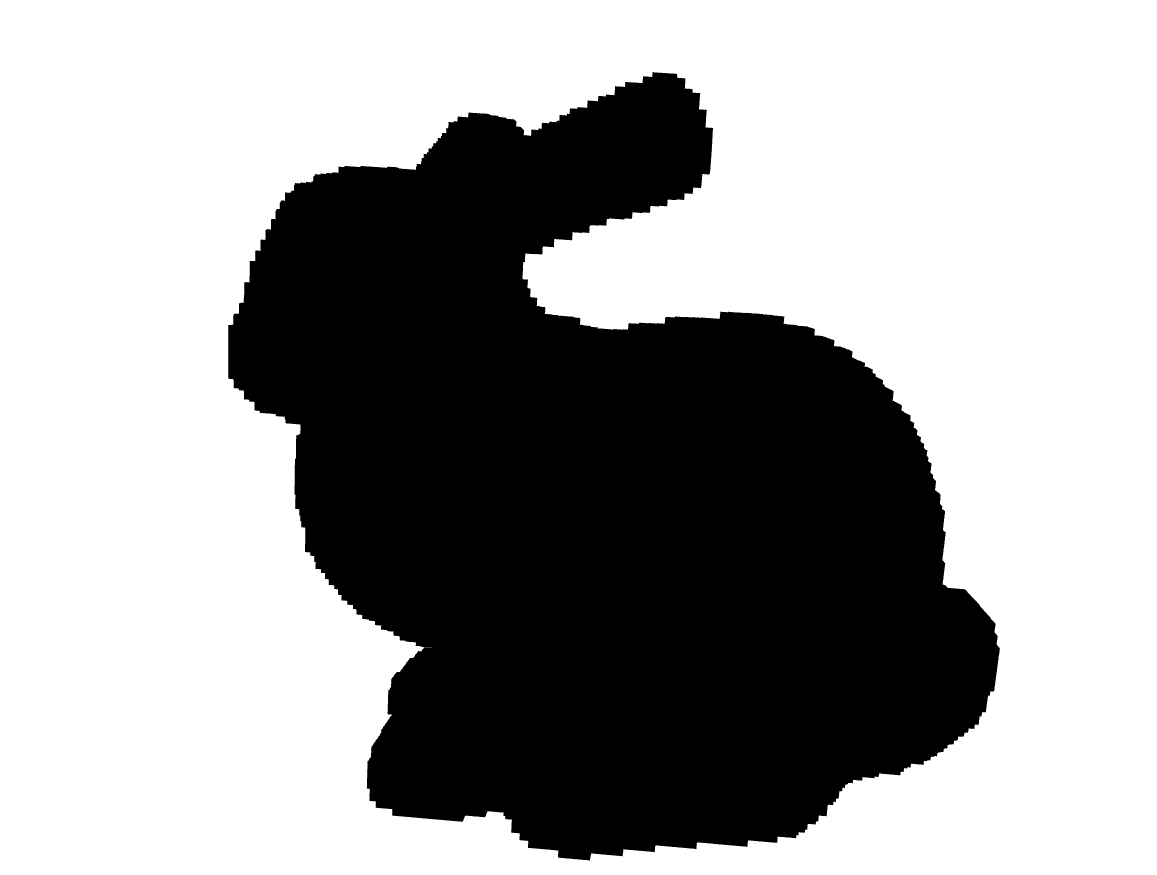